### Linear Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

In [6]:
class Regression:

    def __init__(self, dim):
        self.w = np.zeros((dim, 1))
        self.ws = [self.w.copy()]
        self.eta = 0.01
        
    def predict(self,x):
        # Make prediction 
        pred = x @ self.w
        return pred
    
    def grad(self,T,pred,x):
        ## the gradient of the sum of squared errors with respect to w
        grd = - (T - pred) * x
        return grd
    
    def model_update(self,grd):
        # Update w: take a smallstep in the direction of the negative gradient
        self.w -= self.eta * grd

In [7]:
nSamples = 100
X = np.random.uniform(0, 10, size=(nSamples, 1))
rnd = np.random.normal(0, 0.2, size=(nSamples, 1))
T = 2 - 0.1 * X + rnd + 0.0 * (X - 3)**2 
# Change 0 to 0.05 to try to fit nonlinear data

X1 = np.insert(X, 0, 1, axis=1) ## insert bias

X1.shape, T.shape

((100, 2), (100, 1))

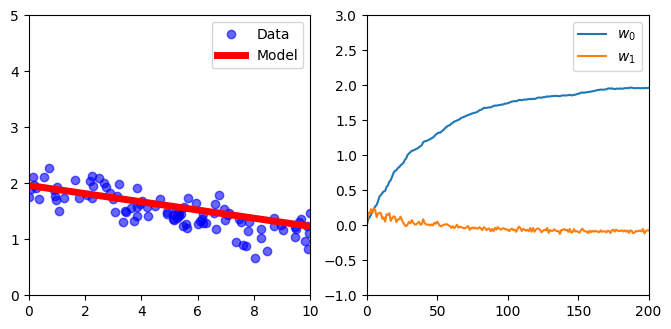

In [19]:
nFrames = 2000
nUpdatesPerFrame = 10
nIterations = nFrames // nUpdatesPerFrame

model = Regression(X1.shape[1])

fig = plt.figure(figsize=(8, 8))

for step in range(nIterations):
    plt.clf()
    for i in range(nUpdatesPerFrame):
        #step += 1
        #n = step % nSamples
        n = np.random.randint(0,100, size=1)[0]
        
        predicted = model.predict(X1[n:n+1, :])
        
        grd = model.grad(T[n:n+1, :],predicted,X1[n:n+1, :].T) 
        
        model.model_update(grd)
        
        
    model.ws.append(model.w.copy())
 
    plt.subplot(2, 2, 1)
    plt.plot(X, T, 'bo', alpha=0.6)
    xs = np.linspace(0, 10, 100).reshape((-1, 1))
    xs1 = np.insert(xs, 0, 1, axis=1)
    plt.plot(xs, xs1 @ model.w, 'r-', linewidth=5)
    plt.legend(('Data','Model'), loc='upper right')
    plt.xlim(0, 10)
    plt.ylim(0, 5)

    plt.subplot(2, 2, 2)
    plt.plot(np.array(model.ws)[:, :, 0])
    plt.xlim(0, nIterations)
    plt.ylim(-1, 3)
    plt.legend(('$w_0$', '$w_1$'))

    ipd.clear_output(wait=True)
    ipd.display(fig)
    
ipd.clear_output(wait=True)